In [1]:
import os
import numpy as np
import scipy.integrate
import scipy as sp
import matplotlib.pyplot as plt
from numpy import sqrt
from numpy.linalg import norm
import scipy.io as scio
from scipy import interpolate
import scipy.special as special
import math
from numpy import tanh, cosh, sqrt, cos, sin, exp, log, pi
from scipy.integrate import quad, quad_vec
from scipy.optimize import fsolve, bisect, dual_annealing

In [2]:
# Chose between rademacher or gaussian theory

#opt = 'rad'
opt = 'gauss'

In [ ]:
from scipy.interpolate import InterpolatedUnivariateSpline
import matplotlib.pyplot as plt
import os
import numpy as np

CSV_PATH = "ones_nonsymm_05_mmse_only.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV file not found: {CSV_PATH}. Make sure the file is in the current directory.")

# Load the CSV: file expected as 2 rows x Ncols OR transposed (N x 2)
data = np.loadtxt(CSV_PATH, delimiter=',')
if data.ndim != 2:
    raise ValueError("Unexpected CSV contents")

# --- Minimal change: support 2-row file instead of 3-row ---
if data.shape[0] == 2 and data.shape[1] >= 2:
    rows = data
elif data.shape[1] == 2 and data.shape[0] >= 2:
    rows = data.T
else:
    raise ValueError("CSV must contain exactly 2 rows (l, mmse) or be transposable to that shape.")

l_nodes = rows[0, :].astype(float)
mmse_nodes = rows[1, :].astype(float)

# Ensure monotonic increasing l
sort_idx = np.argsort(l_nodes)
l_nodes = l_nodes[sort_idx]
mmse_nodes = mmse_nodes[sort_idx]

# Optional safety: ensure mmse(0)=1 if a zero node exists or insert one
tol_zero = 1e-14
zero_idx = np.where(np.abs(l_nodes) <= tol_zero)[0]
if zero_idx.size > 0:
    mmse_nodes[zero_idx[0]] = 1.0
else:
    # Insert zero node at front (minimal intervention)
    l_nodes = np.concatenate(([0.0], l_nodes))
    mmse_nodes = np.concatenate(([1.0], mmse_nodes))

# Build cubic interpolant for mmse (k=3)
mmse_spline = InterpolatedUnivariateSpline(l_nodes, mmse_nodes, k=3)

_IOTA_CSV = "ones_nonsymm_05_with_iota.csv"

if os.path.exists(_IOTA_CSV):
    _data_i = np.loadtxt(_IOTA_CSV, delimiter=',')
    if _data_i.ndim != 2:
        raise ValueError("Unexpected contents in ones_nonsymm_05_with_iota.csv")
    # support either 3 x N or N x 3
    if _data_i.shape[0] == 3 and _data_i.shape[1] >= 2:
        _rows_i = _data_i
    elif _data_i.shape[1] == 3 and _data_i.shape[0] >= 2:
        _rows_i = _data_i.T
    else:
        raise ValueError("ones_nonsymm_05_with_iota.csv must contain 3 rows (l, mmse, iota) or be transposable to that shape.")
    _l_i = _rows_i[0, :].astype(float)
    _iota_nodes = _rows_i[2, :].astype(float)
    # sort by l
    _si = np.argsort(_l_i)
    _l_i = _l_i[_si]
    _iota_nodes = _iota_nodes[_si]
    # build spline for iota
    _iota_spline = InterpolatedUnivariateSpline(_l_i, _iota_nodes, k=3)
    def _iota_05_vec(x):
        """Return iota(x) from provided CSV spline (scalar or array)."""
        xa = np.asarray(x)
        try:
            out = _iota_spline(xa)
        except Exception:
            # fall back to scalar calls
            vec = np.vectorize(lambda t: float(_iota_spline(t)))
            out = vec(xa)
        return float(out) if out.shape == () else out
else:
    _ant = mmse_spline.antiderivative()
    _ant0 = float(_ant(0.0))
    def _iota_05_vec(x):
        xa = np.asarray(x)
        vals = _ant(xa) - _ant0
        out = 0.5 * vals
        return float(out) if out.shape == () else out

def mmse_interp_05(x):
    return mmse_spline(x)

def _m_05_vec(l):

    l = np.asarray(l)
    try:
        mm = mmse_interp_05(l)         # spline supports arrays
        mm = np.asarray(mm)
        return 1.0 - mm
    except Exception:
        vec = np.vectorize(lambda x: 1.0 - float(mmse_interp_05(x)))
        return np.asarray(vec(l))


def m_s_inv_05_fast(target, bracket_hi=1.0, max_hi=1e6):
    targ = np.asarray(target)

    # Otherwise: non-monotonic -> fallback to scalar brentq (vectorized)
    def f_scalar(l, targ_scalar):
        # evaluate m_05 robustly at scalar l
        val = _m_05_vec(np.array([l]))  # shape (1,)
        return float(val[0]) - float(targ_scalar)

    def invert_one(t):
        # scalar inversion using brentq with bracket-doubling (the old robust strategy)
        f0 = f_scalar(0.0, t)
        if abs(f0) < 1e-12:
            return 0.0
        lo = 0.0
        hi = float(bracket_hi)
        fhi = f_scalar(hi, t)
        if f0 * fhi <= 0:
            try:
                return float(brentq(lambda x: f_scalar(x, t), lo, hi, xtol=1e-12, maxiter=200))
            except Exception:
                pass
        # doubling
        while f0 * fhi > 0 and hi < max_hi:
            hi *= 2.0
            fhi = f_scalar(hi, t)
        if f0 * fhi > 0:
            return 0.0 if abs(f0) <= abs(fhi) else float(hi)
        return float(brentq(lambda x: f_scalar(x, t), lo, hi, xtol=1e-12, maxiter=200))

    # vectorize invert_one across the target array
    v_invert = np.vectorize(invert_one, otypes=[float])
    res = v_invert(targ.ravel())
    res = res.reshape(targ.shape)
    return float(res) if res.shape == () else res


def derivative_mmse_05_fast(l, ratio=None, h=1e-6):
    l_arr = np.asarray(l, dtype=float)
    scalar_input = (l_arr.shape == ())

    # 1) prefer analytic spline derivative if available
    try:
        if 'mmse_spline' in globals() and hasattr(globals()['mmse_spline'], 'derivative'):
            deriv_spline = globals()['mmse_spline'].derivative()
            res = deriv_spline(l_arr)   # supports scalar or array
            res = np.asarray(res, dtype=float)
            return float(res) if scalar_input else res
        # If mmse_interp_05 itself has derivative attribute (unlikely), use it:
        if hasattr(mmse_interp_05, 'derivative'):
            deriv_callable = mmse_interp_05.derivative()
            res = deriv_callable(l_arr)
            res = np.asarray(res, dtype=float)
            return float(res) if scalar_input else res
    except Exception:
        # fall back to finite-difference below
        pass

    # 2) Finite-difference fallback (vectorized)
    # We'll compute mm(l+h) and mm(l-h) vectorized, but handle near-zero points.
    h = float(h)
    # compute shifted arrays
    l_plus = l_arr + h
    l_minus = l_arr - h

    # Where l_minus >= 0 use central difference; else use forward difference
    mask_central = (l_minus >= 0.0)

    res = np.empty_like(l_arr, dtype=float)

    if np.any(mask_central):
        mm_plus = np.asarray(mmse_interp_05(l_plus[mask_central]))
        mm_minus = np.asarray(mmse_interp_05(l_minus[mask_central]))
        res[mask_central] = (mm_plus - mm_minus) / (2.0 * h)

    if np.any(~mask_central):
        # forward difference for l near zero
        idx = np.nonzero(~mask_central)[0]
        mm0 = np.asarray(mmse_interp_05(l_arr[~mask_central]))
        mm1 = np.asarray(mmse_interp_05(l_plus[~mask_central]))
        res[~mask_central] = (mm1 - mm0) / h

    return float(res) if scalar_input else res


In [ ]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import brentq

# --- Gauss-Hermite setup (choose order; 40 is usually very accurate) ---
_GH_ORDER = 40
_GH_x, _GH_w = hermgauss(_GH_ORDER)               # nodes x_i, weights w_i for e^{-x^2}
_GH_scale = 1.0/np.sqrt(np.pi)                    # factor described below

# For standard normal integrals: 
# ∫ f(z) φ(z) dz ≈ (1/√π) * Σ_i w_i * f(√2 * x_i)

def _gauss_hermite_expectation(f_vals_at_scaled_nodes):
    # weights scaled by 1/√π
    return np.tensordot(_GH_w * _GH_scale, f_vals_at_scaled_nodes, axes=(0,0))


def psi_w_vec(l_arr, opt='rad'):
    l = np.asarray(l_arr, dtype=float)
    if opt == 'gauss':
        # psi_w(l) = l/(1+l), can broadcast
        return l / (1.0 + l)

    # opt == 'rad' -> integral: E_z[ tanh(sqrt(l) * z + l) ] where z ~ N(0,1)
    scalar_input = (l.ndim == 0)
    l = l.ravel() if not scalar_input else l.reshape(1)
    # compute scaled nodes: z_i = sqrt(2) * x_i, shape (N,)
    z_nodes = np.sqrt(2.0) * _GH_x                       # shape (N,)
    # we need sqrt(l) * z + l for each l and each z -> produce shape (N, L)
    # do it with broadcasting: z_nodes[:,None] * sqrt_l[None,:] + l[None,:]
    sqrt_l = np.sqrt(np.maximum(l, 0.0))                 # shape (L,)
    arg = z_nodes[:, None] * sqrt_l[None, :] + l[None, :]  # (N, L)
    vals = np.tanh(arg)                                  # (N, L)
    exps = _gauss_hermite_expectation(vals)              # shape (L,)
    return exps.reshape(()) if scalar_input else exps


def psi_vec(g_arr, opt='rad'):
    g = np.asarray(g_arr, dtype=float)
    if opt == 'gauss':
        return 0.5 * g - 0.5 * np.log(1.0 + g)

    # rad case: psi(g) = -g/2 + E_z[ log cosh( sqrt(g)*z + g ) ]
    scalar_input = (g.ndim == 0)
    g = g.ravel() if not scalar_input else g.reshape(1)
    z_nodes = np.sqrt(2.0) * _GH_x                         # shape (N,)
    sqrt_g = np.sqrt(np.maximum(g, 0.0))                   # shape (L,)
    arg = z_nodes[:, None] * sqrt_g[None, :] + g[None, :]  # (N, L)
    vals = np.log(np.cosh(arg))                            # (N, L)
    exps = _gauss_hermite_expectation(vals)                # (L,)
    out = -0.5 * g + exps
    return out.reshape(()) if scalar_input else out

def m_inv_vec(q, opt='rad'):
    q_arr = np.atleast_1d(q).astype(float)
    out = np.empty_like(q_arr)

    if opt == 'gauss':
        out = q_arr / (1.0 - q_arr)
        return out if q_arr.shape != () else out.item()

    # rad: do bracket search by doubling until psi_w(u) >= q
    for idx, qv in enumerate(q_arr):
        if qv <= 0:
            out[idx] = 0.0
            continue
        # find u such that psi_w(u) >= qv
        lo = 0.0
        hi = 1.0
        # fast check (psi_w_vec supports vectorized calls)
        # double hi until sufficient or until a safe cap
        while psi_w_vec(hi, opt=opt) < qv:
            hi *= 2.0
            if hi > 1e6:
                # give up and set large value
                break
        # now root-find on [lo, hi] for f(l) = psi_w(l) - qv
        f = lambda x: psi_w_vec(x, opt=opt) - qv
        # brentq needs scalar callable; psi_w_vec is fast because GH quadrature is vectorized
        root = brentq(f, lo, hi, maxiter=100, xtol=1e-12)
        out[idx] = root

    return out if q_arr.shape != () else out.item()


def EE_s(arr, P_v):
    P_v = np.asarray(P_v)
    return np.tensordot(P_v, arr, axes=(0, 0))


def EE_s_g(q_W, v, P_v, g):
    q_W = np.asarray(q_W)
    v = np.asarray(v)
    P_v = np.asarray(P_v)
    return np.dot(P_v, (v**2) * g(q_W))


def EE_s_qW2(q_W, v, P_v):
    q_W = np.asarray(q_W)
    v = np.asarray(v)
    P_v = np.asarray(P_v)
    return np.dot(P_v, (v**2) * (q_W**2))


def EE_FSB(mat, arr, P_v):
    # ensure numpy arrays
    mat = np.asarray(mat)
    arr = np.asarray(arr)
    P_v = np.asarray(P_v)
    return mat.dot(P_v * arr)


def mmse_qW_NSB_FSB_fast(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_2, g_2_prime,
    v, P_v, s2, P_s2,
    coeff_1, coeff_2, alpha, gamma_1, gamma_2, delta,
    max_iter=3000, tol=1e-8, damp=0.1, quench=False,
    opt='gauss'
):

    # copy inputs & shapes
    q_W_1 = np.asarray(q_W_1_init, dtype=float).copy()     # (S,)
    q_W_2 = np.asarray(q_W_2_init, dtype=float).copy()     # (V, S)
    q_W_12 = np.asarray(q_W_12_init, dtype=float).copy()   # (V,)
    v = np.asarray(v, dtype=float)
    P_v = np.asarray(P_v, dtype=float)
    s2 = np.asarray(s2, dtype=float)
    P_s2 = np.asarray(P_s2, dtype=float)

    V = v.shape[0]
    S = s2.shape[0]
    assert q_W_1.shape == (S,)
    assert q_W_2.shape[0] == V and q_W_2.shape[1] == S
    assert q_W_12.shape == (V,)

    # constants
    mu1_sq = coeff_1[1]**2
    mu2_sq = coeff_2[1]**2

    alpha_over_gamma1 = alpha / gamma_1
    alpha_over_gamma2 = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1 = gamma_2 / gamma_1
    inv_gamma1 = 1.0 / gamma_1

    Pv = P_v
    Pv_v2 = Pv * (v**2)   # shape (V,)

    # initial r_K and q_K (same as slow)
    r_K = mu1_sq * mu2_sq + mu2_sq * g_1(1.0) + g_2(mu1_sq + g_1(1.0))
    q_K = (
        mu1_sq * mu2_sq
        + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
        + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2), v, P_v, g_2)
    )

    # preallocate reusable arrays
    r_W_1 = np.empty(S, dtype=float)         # (S,)
    r_W_2 = np.empty((V, S), dtype=float)    # (V,S)

    tiny = 1e-14   # small safety for dividing by derivatives / denominators

    for it in range(max_iter):
        denom = (delta + r_K - q_K)   # scalar
        if denom <= 0:
            raise RuntimeError(f"denom <= 0 (delta + r_K - q_K) = {denom} at iter {it}")

        # --- Precompute arrays depending on current q's ---
        g1_qW1 = g_1(q_W_1)                     # (S,)
        g1p_qW1 = g_1_prime(q_W_1)              # (S,)

        EE_FSB_val = EE_FSB(q_W_2, g1_qW1, P_s2)  # (V,)   <-- sums over s2 with weights P_s2
        inner = mu1_sq * q_W_12 + EE_FSB_val      # (V,)
        g2p_inner = g_2_prime(inner)              # (V,)
        v2_g2p_inner = (v**2) * g2p_inner         # (V,)

        # --- r_W_12: vector over v  (matches slow) ---
        r_W_12 = (alpha_over_gamma2 * mu2_sq * v2_g2p_inner) / denom   # (V,)

        # --- tau_v and q_W_12 update (vectorized) ---
        # tau_v solves m_05(tau_v) = EE_FSB(q_W_2, q_W_1, P_s2)
        EE_FSB_qW2_qW1 = EE_FSB(q_W_2, q_W_1, P_s2)   # (V,)
        tau_v = m_s_inv_05_fast(EE_FSB_qW2_qW1)       # (V,) or scalar broadcast -> we expect (V,)

        # q_W_12 <- m_05(tau_v + r_W_12)
        q_W_12_new = _m_05_vec(tau_v + r_W_12)        # (V,)
        q_W_12 = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # recompute inner arrays (they depend on q_W_12)
        inner = mu1_sq * q_W_12 + EE_FSB_val
        g2p_inner = g_2_prime(inner)
        v2_g2p_inner = (v**2) * g2p_inner

        # --- r_W_1 (vectorized over s) ---
        # termA: alpha/gamma_1 * mu2_sq * s2^2 * g1p_qW1 / denom
        termA = (alpha_over_gamma1 * mu2_sq / denom) * (s2**2) * g1p_qW1   # (S,)

        # termB: alpha/gamma_1 * EE_v[ v^2 * g2p_inner * q_W_2[:,t] ] * g1p_qW1 / denom
        # compute Pv-weighted vector Pv_v2 * g2p_inner (V,)
        Pv_v2_g2p = Pv_v2 * g2p_inner   # (V,)
        # S_vec[t] = sum_v Pv_v2_g2p[v] * q_W_2[v,t]  -> dot over v
        S_vec = np.dot(Pv_v2_g2p, q_W_2)   # (S,)
        termB = (alpha_over_gamma1 / denom) * (g1p_qW1 * S_vec)   # (S,)

        # termC: gamma2/gamma1 * EE_v[ (q_W_12 - EE_FSB_qW2_qW1)/(-dmmse_v) * q_W_2[:,t] ]
        dmmse_v = derivative_mmse_05_fast(tau_v)   # (V,)
        # protect tiny derivatives
        dmmse_v_safe = np.where(np.abs(dmmse_v) < tiny, np.sign(dmmse_v) * tiny, dmmse_v)
        weight_R = (q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe)   # (V,)
        # C_vec[t] = sum_v P_v[v] * weight_R[v] * q_W_2[v,t]
        C_vec = np.dot(P_v * weight_R, q_W_2)    # (S,)
        termC = gamma2_over_gamma1 * C_vec      # (S,)

        r_W_1 = termA + termB + termC    # (S,)

        # --- r_W_2 (V,S) vectorized ---
        pref1 = alpha_over_gamma1_gamma2 / denom   # scalar
        # first part: pref1 * v2_g2p_inner[:,None] * g1_qW1[None,:]
        # write into r_W_2 (reuse array)
        np.multiply(v2_g2p_inner[:, None], g1_qW1[None, :], out=r_W_2)  # r_W_2 = outer(v2_g2p_inner, g1_qW1)
        r_W_2 *= pref1

        # second part: (1/gamma_1) * ((q_W_12 - EE_FSB_qW2_qW1)/(-dmmse_v))[:,None] * q_W_1[None,:]
        tmp = ((q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe))[:, None] * q_W_1[None, :]
        r_W_2 += (inv_gamma1 * tmp)

        # --- update q_W's via psi mapping (vectorized) ---
        # psi mapping: for gaussian prior psi_w_vec(r) = r/(1+r)
        q_W_1_new = psi_w_vec(r_W_1, opt=opt)   # (S,)
        q_W_1 = (1.0 - damp) * q_W_1 + damp * q_W_1_new

        if quench:
            q_W_1[:] = 1.0

        q_W_2_new = psi_w_vec(r_W_2, opt=opt)   # (V,S)
        q_W_2 = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        # --- update q_K and check convergence ---
        q_K_new = (
            mu1_sq * mu2_sq
            + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
            + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2), v, P_v, g_2)
        )

        if ((np.abs(q_K_new - q_K) < tol)):
            q_K = q_K_new
            break

        q_K = q_K_new

    mmse = r_K - q_K
    return mmse, q_W_1, q_W_2, q_W_12

def free_entropy_NSB_FSB(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_2, g_2_prime,
    v, P_v, s2, P_s2,
    coeff_1, coeff_2, alpha, gamma_1, gamma_2, delta,
    max_iter=3000, tol=1e-8, damp=0.1, quench=False,
    opt='gauss'):
    
    # copy inputs & shapes
    q_W_1 = np.asarray(q_W_1_init, dtype=float).copy()     # (S,)
    q_W_2 = np.asarray(q_W_2_init, dtype=float).copy()     # (V, S)
    q_W_12 = np.asarray(q_W_12_init, dtype=float).copy()   # (V,)
    v = np.asarray(v, dtype=float)
    P_v = np.asarray(P_v, dtype=float)
    s2 = np.asarray(s2, dtype=float)
    P_s2 = np.asarray(P_s2, dtype=float)

    V = v.shape[0]
    S = s2.shape[0]
    assert q_W_1.shape == (S,)
    assert q_W_2.shape[0] == V and q_W_2.shape[1] == S
    assert q_W_12.shape == (V,)

    # constants
    mu1_sq = coeff_1[1]**2
    mu2_sq = coeff_2[1]**2

    alpha_over_gamma1 = alpha / gamma_1
    alpha_over_gamma2 = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1 = gamma_2 / gamma_1
    inv_gamma1 = 1.0 / gamma_1

    Pv = P_v
    Pv_v2 = Pv * (v**2)   # shape (V,)

    # initial r_K and q_K (same as slow)
    r_K = mu1_sq * mu2_sq + mu2_sq * g_1(1.0) + g_2(mu1_sq + g_1(1.0))
    q_K = (
        mu1_sq * mu2_sq
        + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
        + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2), v, P_v, g_2)
    )

    # preallocate reusable arrays
    r_W_1 = np.empty(S, dtype=float)         # (S,)
    r_W_2 = np.empty((V, S), dtype=float)    # (V,S)

    tiny = 1e-14   # small safety for dividing by derivatives / denominators

    for it in range(2):
        denom = (delta + r_K - q_K)   # scalar
        if denom <= 0:
            raise RuntimeError(f"denom <= 0 (delta + r_K - q_K) = {denom} at iter {it}")

        # --- Precompute arrays depending on current q's ---
        g1_qW1 = g_1(q_W_1)                     # (S,)
        g1p_qW1 = g_1_prime(q_W_1)              # (S,)

        EE_FSB_val = EE_FSB(q_W_2, g1_qW1, P_s2)  # (V,)   <-- sums over s2 with weights P_s2
        inner = mu1_sq * q_W_12 + EE_FSB_val      # (V,)
        g2p_inner = g_2_prime(inner)              # (V,)
        v2_g2p_inner = (v**2) * g2p_inner         # (V,)

        # --- r_W_12: vector over v  (matches slow) ---
        r_W_12 = (alpha_over_gamma2 * mu2_sq * v2_g2p_inner) / denom   # (V,)

        # --- tau_v and q_W_12 update (vectorized) ---
        # tau_v solves m_05(tau_v) = EE_FSB(q_W_2, q_W_1, P_s2)
        EE_FSB_qW2_qW1 = EE_FSB(q_W_2, q_W_1, P_s2)   # (V,)
        tau_v = m_s_inv_05_fast(EE_FSB_qW2_qW1)       # (V,) or scalar broadcast -> we expect (V,)

        # q_W_12 <- m_05(tau_v + r_W_12)
        q_W_12_new = _m_05_vec(tau_v + r_W_12)        # (V,)
        q_W_12 = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # recompute inner arrays (they depend on q_W_12)
        inner = mu1_sq * q_W_12 + EE_FSB_val
        g2p_inner = g_2_prime(inner)
        v2_g2p_inner = (v**2) * g2p_inner

        # --- r_W_1 (vectorized over s) ---
        # termA: alpha/gamma_1 * mu2_sq * s2^2 * g1p_qW1 / denom
        termA = (alpha_over_gamma1 * mu2_sq / denom) * (s2**2) * g1p_qW1   # (S,)

        # termB: alpha/gamma_1 * EE_v[ v^2 * g2p_inner * q_W_2[:,t] ] * g1p_qW1 / denom
        # compute Pv-weighted vector Pv_v2 * g2p_inner (V,)
        Pv_v2_g2p = Pv_v2 * g2p_inner   # (V,)
        # S_vec[t] = sum_v Pv_v2_g2p[v] * q_W_2[v,t]  -> dot over v
        S_vec = np.dot(Pv_v2_g2p, q_W_2)   # (S,)
        termB = (alpha_over_gamma1 / denom) * (g1p_qW1 * S_vec)   # (S,)

        # termC: gamma2/gamma1 * EE_v[ (q_W_12 - EE_FSB_qW2_qW1)/(-dmmse_v) * q_W_2[:,t] ]
        dmmse_v = derivative_mmse_05_fast(tau_v)   # (V,)
        # protect tiny derivatives
        dmmse_v_safe = np.where(np.abs(dmmse_v) < tiny, np.sign(dmmse_v) * tiny, dmmse_v)
        weight_R = (q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe)   # (V,)
        # C_vec[t] = sum_v P_v[v] * weight_R[v] * q_W_2[v,t]
        C_vec = np.dot(P_v * weight_R, q_W_2)    # (S,)
        termC = gamma2_over_gamma1 * C_vec      # (S,)

        r_W_1 = termA + termB + termC    # (S,)

        # --- r_W_2 (V,S) vectorized ---
        pref1 = alpha_over_gamma1_gamma2 / denom   # scalar
        # first part: pref1 * v2_g2p_inner[:,None] * g1_qW1[None,:]
        # write into r_W_2 (reuse array)
        np.multiply(v2_g2p_inner[:, None], g1_qW1[None, :], out=r_W_2)  # r_W_2 = outer(v2_g2p_inner, g1_qW1)
        r_W_2 *= pref1

        # second part: (1/gamma_1) * ((q_W_12 - EE_FSB_qW2_qW1)/(-dmmse_v))[:,None] * q_W_1[None,:]
        tmp = ((q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe))[:, None] * q_W_1[None, :]
        r_W_2 += (inv_gamma1 * tmp)

        # --- update q_W's via psi mapping (vectorized) ---
        # psi mapping: for gaussian prior psi_w_vec(r) = r/(1+r)
        q_W_1_new = psi_w_vec(r_W_1, opt=opt)   # (S,)
        q_W_1 = (1.0 - damp) * q_W_1 + damp * q_W_1_new

        if quench:
            q_W_1[:] = 1.0

        q_W_2_new = psi_w_vec(r_W_2, opt=opt)   # (V,S)
        q_W_2 = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        # --- update q_K and check convergence ---
        q_K_new = (
            mu1_sq * mu2_sq
            + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
            + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2), v, P_v, g_2)
        )

        if ((np.abs(q_K_new - q_K) < tol)):
            q_K = q_K_new
            break

        q_K = q_K_new

    f_RS = ( -np.log(2*np.pi*np.exp(1)*(delta + r_K - q_K))*0.5
         + (gamma_1/alpha) * np.dot(P_s2, (psi_vec(r_W_1, opt=opt) - 0.5 * q_W_1 * r_W_1))
         + (gamma_1*gamma_2/alpha) * np.sum(P_v[:,None] * P_s2[None,:] * (psi_vec(r_W_2, opt=opt) - 0.5 * q_W_2 * r_W_2))
         + (gamma_2/alpha) * np.dot(P_v, 0.5 * r_W_12 * (1.0 - q_W_12) - (_iota_05_vec(tau_v + r_W_12) - _iota_05_vec(tau_v))) )    
    return f_RS
    

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def get_discrete_gaussian_on_grid(num_v, mu, sigma, mult_sigma):
    # Create a grid of states between -mult_sigma*sigma and mult_sigma*sigma
    v = np.linspace(mu-mult_sigma*sigma, mu+mult_sigma*sigma, num_v)
    # Compute unnormalized probabilities using the Gaussian pdf with mean mu and variance sigma^2
    weights = np.exp(-((v-mu)**2) / (2*sigma**2)) / np.sqrt(2 * np.pi * sigma**2)
    # Normalize the weights to get probabilities
    P_v = weights / np.sum(weights)
    return v, P_v    

In [9]:
def hermite_coefficients(func, n, a, b):

    # Define the Hermite polynomials
    def hermite(x, n):
        if n == 0:
            return 1
        elif n == 1:
            return x
        else:
            return x * hermite(x, n - 1) - (n - 1) * hermite(x, n - 2)

    # Define the weight function
    def weight(x):
        return np.exp(-x**2/2)/np.sqrt(2*np.pi)

    # Compute the coefficients
    coefficients = []
    for i in range(n+1):
        # Use scipy.integrate.quad to compute the integral numerically.
        # Note: The integrand needs to be defined as a lambda function.
        integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)
        coefficients.append(integral)

    return np.array(coefficients)

C:\Users\rudys\AppData\Local\Temp\ipykernel_56628\1956909808.py:21: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)


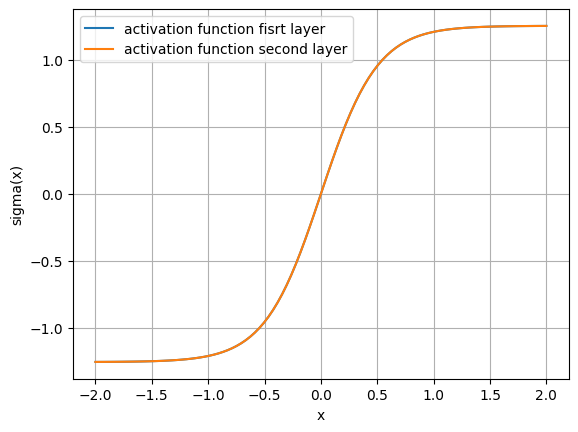

[ 0.00000000e+00  9.15241581e-01  0.00000000e+00 -7.70333160e-01
  0.00000000e+00  1.96127188e+00  0.00000000e+00 -8.38348577e+00
  0.00000000e+00  5.04972045e+01  0.00000000e+00 -3.93355039e+02
  0.00000000e+00  3.76468557e+03  0.00000000e+00 -4.27840791e+04
  0.00000000e+00  5.63449142e+05  0.00000000e+00 -8.44293231e+06
  0.00000000e+00  1.41906748e+08  0.00000000e+00 -2.64496885e+09]
[ 0.00000000e+00  9.15241581e-01  0.00000000e+00 -7.70333160e-01
  0.00000000e+00  1.96127188e+00  0.00000000e+00 -8.38348577e+00
  0.00000000e+00  5.04972045e+01  0.00000000e+00 -3.93355039e+02
  0.00000000e+00  3.76468557e+03  0.00000000e+00 -4.27840791e+04
  0.00000000e+00  5.63449142e+05  0.00000000e+00 -8.44293231e+06
  0.00000000e+00  1.41906748e+08  0.00000000e+00 -2.64496885e+09]
0.9999999999999999
0.9999999999999999


In [10]:
# choose the activation function among the activations below
# the cell computes the first num_coeff Hermite coefficients and defines the function g()

activation_1 = 'Tanh unitary'
activation_2 = 'Tanh unitary'
num_coeff = 23

if (activation_1 == 'Linear'):

    def sigma_1(x):
        return x

elif (activation_1 == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_1(x):
        return np.tanh(2*x)/np.sqrt(var)   

elif (activation_1 == 'Tanh unitary no linear'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x) - 0.729477531486114827430355944671*x)**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_1(x):
        return (np.tanh(2*x) - 0.729477531486114827430355944671*x)/np.sqrt(var) 

if (activation_2 == 'Linear'):

    def sigma_2(x):
        return x

elif (activation_2 == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_2(x):
        return np.tanh(2*x)/np.sqrt(var)   

elif (activation_2 == 'Tanh unitary no linear'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x) - 0.729477531486114827430355944671*x)**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_2(x):
        return (np.tanh(2*x) - 0.729477531486114827430355944671*x)/np.sqrt(var)         
          
    
coefficients_1 = hermite_coefficients(lambda x: sigma_1(x), num_coeff, -10, 10)
coefficients_2 = hermite_coefficients(lambda x: sigma_2(x), num_coeff, -10, 10)

  # Create the approximation function using the computed coefficients
def g_1_func(x):
    g = 0
    for i in range(3,len(coefficients_1)):
      g += coefficients_1[i]**2 * x**i / math.factorial(i)
    return g

def g_1_prime(x):
    g = 0
    for i in range(3,len(coefficients_1)):
      g += coefficients_1[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

def g_2_func(x):
    g = 0
    for i in range(3,len(coefficients_2)):
      g += coefficients_2[i]**2 * x**i / math.factorial(i)
    return g

def g_2_prime(x):
    g = 0
    for i in range(3,len(coefficients_2)):
      g += coefficients_2[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

# Plot the original function
x = np.linspace(-2, 2, 100)
plt.plot(x, sigma_1(x), label='activation function fisrt layer')
plt.plot(x, sigma_2(x), label='activation function second layer')

plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()
plt.grid(True)
plt.show()

print(coefficients_1)
print(coefficients_2)
var_activ_1, error_activ_1 = scipy.integrate.quad(lambda x: sigma_1(x)**2 * np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
var_activ_2, error_activ_2 = scipy.integrate.quad(lambda x: sigma_2(x)**2 * np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
print(var_activ_1)
print(var_activ_2)

In [12]:
# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha
mult_sigma = 5  
num_s2 = 100  # Number of states of s2
num_v = 100  # Number of states of v
mean_v = 0  # Mean of the Gaussian prior on v
std_v = 1  # Standard deviation of the Gaussian prior on v
mean_s2 = 0
std_s2 = np.sqrt(mean_v**2+std_v**2)
s2_gauss, P_s2_gauss = get_discrete_gaussian_on_grid(num_v,mean_s2,std_s2,mult_sigma)
v_gauss = [1]
P_v_gauss = [1]

s2_gauss = np.array(s2_gauss)
P_s2_gauss = np.array(P_s2_gauss)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
q_W1_init_info = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_info = 0.99*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo1 = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo1 = 0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo1 = 0*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo2 = 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo2 = 0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo2 = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfoN = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W1_init_unfoN[140:261] = 0.0
q_W2_init_unfoN = 0.0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfoN = 0.0*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_univ= 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_univ = 0.0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_univ = 0.0*np.ones(v_gauss.shape[0]) # initial guess for q_W21

Delta = 0.2
Gamma_1 = 0.5
Gamma_2 = 0.5

# Range of alpha
Alpha_min = 0.01
Alpha_max = 8.5

init = Alpha_min
end = Alpha_max
num = 201

MMSE_NSB_FSB_info = []
q_W_1_NSB_FSB_info = []
q_W_2_NSB_FSB_info = []
q_W_12_NSB_FSB_info = []
q_W_1_NSB_FSB_info_mean = []
q_W_2_NSB_FSB_info_mean = []
q_W_12_NSB_FSB_info_mean = []
free_entropy_NSB_FSB_info = []
MMSE_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1 = []
q_W_2_NSB_FSB_unfo1 = []
q_W_12_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1_mean = []
q_W_2_NSB_FSB_unfo1_mean = []
q_W_12_NSB_FSB_unfo1_mean = []
free_entropy_NSB_FSB_unfo1 = []
MMSE_NSB_FSB_unfo2 = []
q_W_1_NSB_FSB_unfo2 = []
q_W_2_NSB_FSB_unfo2 = []
q_W_12_NSB_FSB_unfo2 = [] 
q_W_1_NSB_FSB_unfo2_mean = []
q_W_2_NSB_FSB_unfo2_mean = []
q_W_12_NSB_FSB_unfo2_mean = []
free_entropy_NSB_FSB_unfo2 = []
MMSE_NSB_FSB_unfoN = []
q_W_1_NSB_FSB_unfoN = []
q_W_2_NSB_FSB_unfoN = []
q_W_12_NSB_FSB_unfoN = [] 
q_W_1_NSB_FSB_unfoN_mean = []
q_W_2_NSB_FSB_unfoN_mean = []
q_W_12_NSB_FSB_unfoN_mean = []
free_entropy_NSB_FSB_unfoN = []
q_W_1_NSB_FSB_univ = []
q_W_2_NSB_FSB_univ = []
q_W_12_NSB_FSB_univ = [] 
MMSE_NSB_FSB_univ = []
q_W_1_NSB_FSB_univ_mean = []
q_W_2_NSB_FSB_univ_mean = []
q_W_12_NSB_FSB_univ_mean = []
free_entropy_NSB_FSB_univ = []


for Alpha in np.linspace(init, end, num=num):
  print('----------------------------------------------------------------')
  print("alpha =",Alpha)
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_info,q_W2_init_info,q_W21_init_info,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_info.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_info.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_info.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_info.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_info_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_info_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_info_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_info.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_unfo1,q_W2_init_unfo1,q_W21_init_unfo1,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_unfo1.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo1.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo1.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo1_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo1_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo1.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))  
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_unfo2,q_W2_init_unfo2,q_W21_init_unfo2,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_unfo2.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo2.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo2.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo2_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo2_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo2.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_unfoN,q_W2_init_unfoN,q_W21_init_unfoN,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_unfoN.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfoN.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfoN.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfoN.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfoN_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfoN_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfoN_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfoN.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_univ,q_W2_init_univ,q_W21_init_univ,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_univ.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_univ.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_univ.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_univ.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_univ_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_univ_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_univ_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_univ.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))


----------------------------------------------------------------
alpha = 0.01
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.052450000000000004
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.0949
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
---------------------------------

C:\Users\rudys\AppData\Local\Temp\ipykernel_56628\4033864689.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=small, loc='lower left')


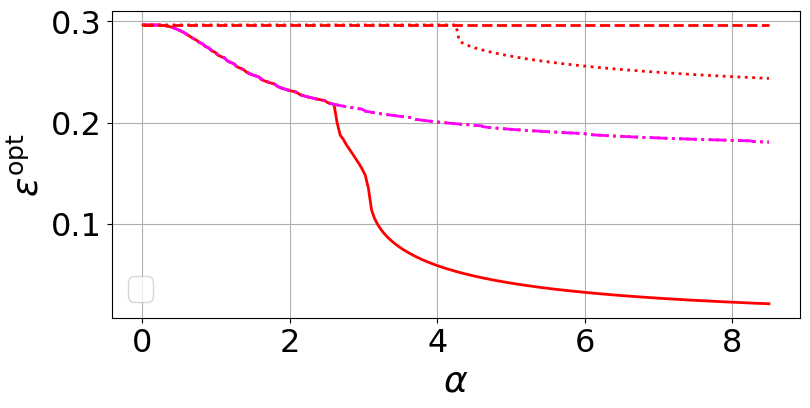

In [13]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

width, height = 7, 5
big, small = int(width*3.8), int(width*3.3)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_info, color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo1, ':', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo2, ':', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfoN, '-.', color='magenta', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_univ, '--', color='red', linewidth=2.0)
#ax.plot(np.linspace(init, end, num=num),(1-coefficients_1[1]**2*coefficients_2[1]**2)*np.ones(np.linspace(init, end, num=num).shape[0]),'--', color='red', linewidth=2.0)
#ax.plot(x, y, label="MT curve")
#ax.scatter(x_sha, y_sha_gamma_1, label="Shallow curve", color='black')
#ax.scatter([1],[0.12], color='purple', s=50, marker='x')

ax.set_xlabel(r'$\alpha$', fontsize=big)
ax.set_ylabel(r'$\varepsilon^{\rm opt}$', fontsize=big)
ax.grid(True)

plt.tight_layout()
plt.legend(fontsize=small, loc='lower left')
plt.tick_params(axis='both', which='major', labelsize=small)
plt.tick_params(axis='both', which='minor', labelsize=small)
#plt.ylim(0.01,0.28)
#plt.xlim(0,4)
plt.show()      

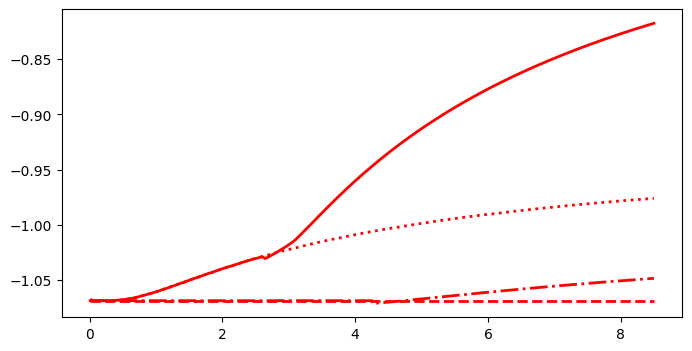

In [14]:
# plot the free entropy in the same way as the mmse
width, height = 7, 5
big, small = int(width*3.8), int(width*3.3)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_info, color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_unfo1, ':', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_unfo2, '-.', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_univ, '--', color='red', linewidth=2.0)


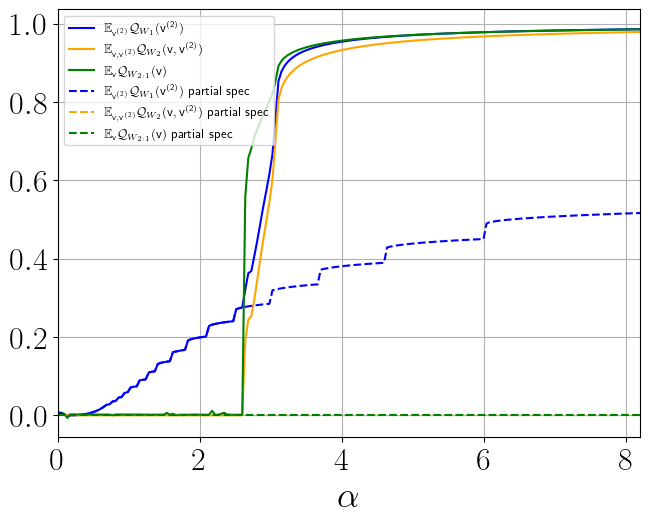

In [15]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsfonts}\usepackage{amssymb}'

smaller = int(width*1.3)

plt.plot(np.linspace(init, end, num=num),np.array(q_W_1_NSB_FSB_info_mean),label=r'$\mathbb{E}_{\mathsf{v^{(2)}}} \mathcal{Q}_{W_1}(\mathsf{v^{(2)}})$',color='blue')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_2_NSB_FSB_info_mean),label=r'$\mathbb{E}_{\mathsf{v},\mathsf{v^{(2)}}} \mathcal{Q}_{W_2}(\mathsf{v},\mathsf{v^{(2)}})$',color='orange')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_12_NSB_FSB_info_mean),label=r'$\mathbb{E}_{\mathsf{v}} \mathcal{Q}_{W_{2:1}}(\mathsf{v})$',color='green')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_1_NSB_FSB_unfo1_mean),'--',label=r'$\mathbb{E}_{\mathsf{v^{(2)}}} \mathcal{Q}_{W_1}(\mathsf{v^{(2)}})$ partial spec',color='blue')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_2_NSB_FSB_unfo1_mean),'--',label=r'$\mathbb{E}_{\mathsf{v},\mathsf{v^{(2)}}} \mathcal{Q}_{W_2}(\mathsf{v},\mathsf{v^{(2)}})$ partial spec',color='orange')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_12_NSB_FSB_unfo1_mean),'--',label=r'$\mathbb{E}_{\mathsf{v}} \mathcal{Q}_{W_{2:1}}(\mathsf{v})$ partial spec',color='green')

plt.tight_layout()
plt.xlabel(r'$\alpha$', fontsize=big)
plt.legend(fontsize=smaller)
plt.tick_params(axis='both', which='major', labelsize=small)
plt.tick_params(axis='both', which='minor', labelsize=small)
plt.xlim(0, 8.2)
plt.grid(True)
plt.show()